<a href="https://colab.research.google.com/github/kazutani2003/EU_M_Math/blob/main/Chap8_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

8-5-1キノコデータセット

In [1]:
import numpy as np
import pandas as pd
import io
import requests

url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data'
res = requests.get(url).content

mushroom = pd.read_csv(io.StringIO(res.decode('utf-8')), header=None)

mushroom.columns =['classes','cap_shape','cap_surface','cap_color','odor','bruises',
                  'gill_attachment','gill_spacing','gill_size','gill_color',
                  'stalk_shape','stalk_root','stalk_surface_above_ring','stalk_surface_below_ring',
                   'stalk_color_above_ring','stalk_color_below_ring','veil_type','veil_color',
                   'ring_number','ring_type','spore_print_color','population','habitat']

mushroom.head()

,classes,cap_shape,cap_surface,cap_color,odor,bruises,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [2]:
print('データの形式:{}'.format(mushroom.shape))
print('欠損の数:{}'.format(mushroom.isnull().sum().sum()))

データの形式:(8124, 23)
欠損の数:0


8-5-2データの整理

In [16]:
mushroom_dummy = pd.get_dummies(mushroom[['gill_color','gill_attachment','odor','cap_color']])
mushroom_dummy.head()

,gill_color_b,gill_color_e,gill_color_g,gill_color_h,gill_color_k,gill_color_n,gill_color_o,gill_color_p,gill_color_r,gill_color_u,...,cap_color_b,cap_color_c,cap_color_e,cap_color_g,cap_color_n,cap_color_p,cap_color_r,cap_color_u,cap_color_w,cap_color_y
0,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [17]:
mushroom_dummy['flg'] = mushroom['classes'].map(lambda x: 1 if x =='p' else 0)

8-5-3エントロピー：不純度の指標

In [18]:
mushroom_dummy.groupby(['cap_color_c', 'flg'])['flg'].count().unstack()

flg,0,1
cap_color_c,,
False,4176,3904
True,32,12


In [6]:
- (0.5 * np.log2(0.5) + 0.5 * np.log2(0.5))

np.float64(1.0)

In [7]:
- (0.001 * np.log2(0.001) + 0.999 * np.log2(0.999))

np.float64(0.011407757737461138)

In [8]:
def calc_entropy(p):
  return - (p *np.log2(p) + (1 - p) * np.log2(1 - p))

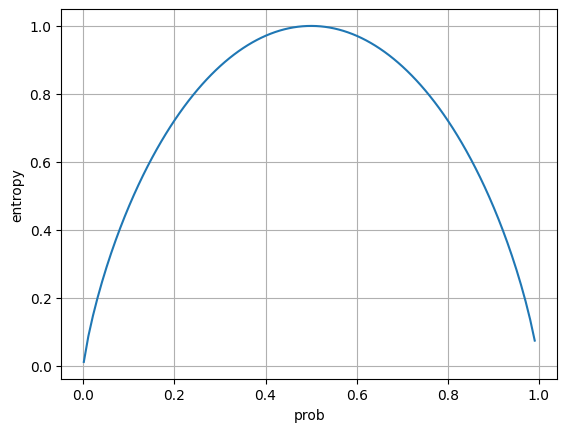

In [10]:
#pの値を0.001から0.999まで0.01刻みで動かす
import matplotlib.pyplot as plt

p = np.arange(0.001, 0.999, 0.01)

#グラフ化
plt.plot(p,calc_entropy(p))
plt.xlabel('prob')
plt.ylabel('entropy')
plt.grid(True)

In [23]:
mushroom_dummy.groupby('flg')['flg'].count()

KeyError: 'flg'

In [25]:
mushroom_dummy = pd.get_dummies(mushroom[['gill_color','gill_attachment','odor','cap_color']])

# 2. 以前入力されたコードで、mushroom_dummy に 'flg' 列を追加する
mushroom_dummy['flg'] = mushroom['classes'].map(lambda x: 1 if x =='p' else 0)
# ※ もし元の列名が 'classes' だった場合は mushroom['classes'].map(...) にしてください

# 3. 正しい変数名（u）で、flg を集計する
mushroom_dummy.groupby('flg')['flg'].count()

,flg
flg,
0,4208
1,3916


In [27]:
entropy_init = -(0.518 * np.log2(0.518) + 0.482 * np.log2(0.482))
print('毒キノコデータのエントロピーの初期値: {:.3f}'.format(entropy_init))

毒キノコデータのエントロピーの初期値: 0.999


8-5-4情報利得：分岐条件の有益さを測る

In [28]:
mushroom_dummy.groupby(['cap_color_c','flg'])['flg'].count().unstack()

flg,0,1
cap_color_c,,
False,4176,3904
True,32,12


In [30]:
p1 = 4176/(4176+3904)
p2 = 1 - p1
entropy_c1 = -(p1*np.log2(p1)+p2*np.log2(p2))
print('entropy_c1:{:.3f}'.format(entropy_c1))

entropy_c1:0.999


In [31]:
entropy_after = (4176+3904)/8124*entropy_c0 + (32+12)/8124*entropy_c1
print('データ分割後の平均エントロピー：{:.3f}'.format(entropy_after))

データ分割後の平均エントロピー：0.999


In [32]:
print('変数cap_colorの分割によって得られる情報利得: (:.3f)'.format(entropy_init - entropy_after))

変数cap_colorの分割によって得られる情報利得: (:.3f)


In [34]:
mushroom_dummy.groupby(['gill_color_b','flg'])['flg'].count().unstack()

flg,0,1
gill_color_b,,
False,4208.0,2188.0
True,NaN,1728.0


In [35]:
p1 = 4176/(4176+2188)
p2 = 1 - p1
entropy_b0 = -(p1*np.log2(p1) + p2*np.log2(p2))

p1 = 0/(0+1728)
p2 = 1 - p1
entropy_b1 = -(p2*np.log2(p2))

entropy_after = (4208+2188)/8124*entropy_b0 + (0+1728)/8124*entropy_b1
print('変数grill_colorの分割によって得られる情報利得:{:.3f}'.format(entropy_init - entropy_after))

変数grill_colorの分割によって得られる情報利得:0.268


8-5-5決定木のモデル構築

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

x = mushroom_dummy.drop('flg', axis = 1)
y = mushroom_dummy['flg']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

model = DecisionTreeClassifier(criterion='entropy',max_depth=5,random_state=0)
model.fit(x_train, y_train)

print('正解率(train):{:.3f}'.format(model.score(x_train, y_train)))
print('正解率(test):{:.3f}'.format(model.score(x_test, y_test)))

正解率(train):0.883
正解率(test):0.893


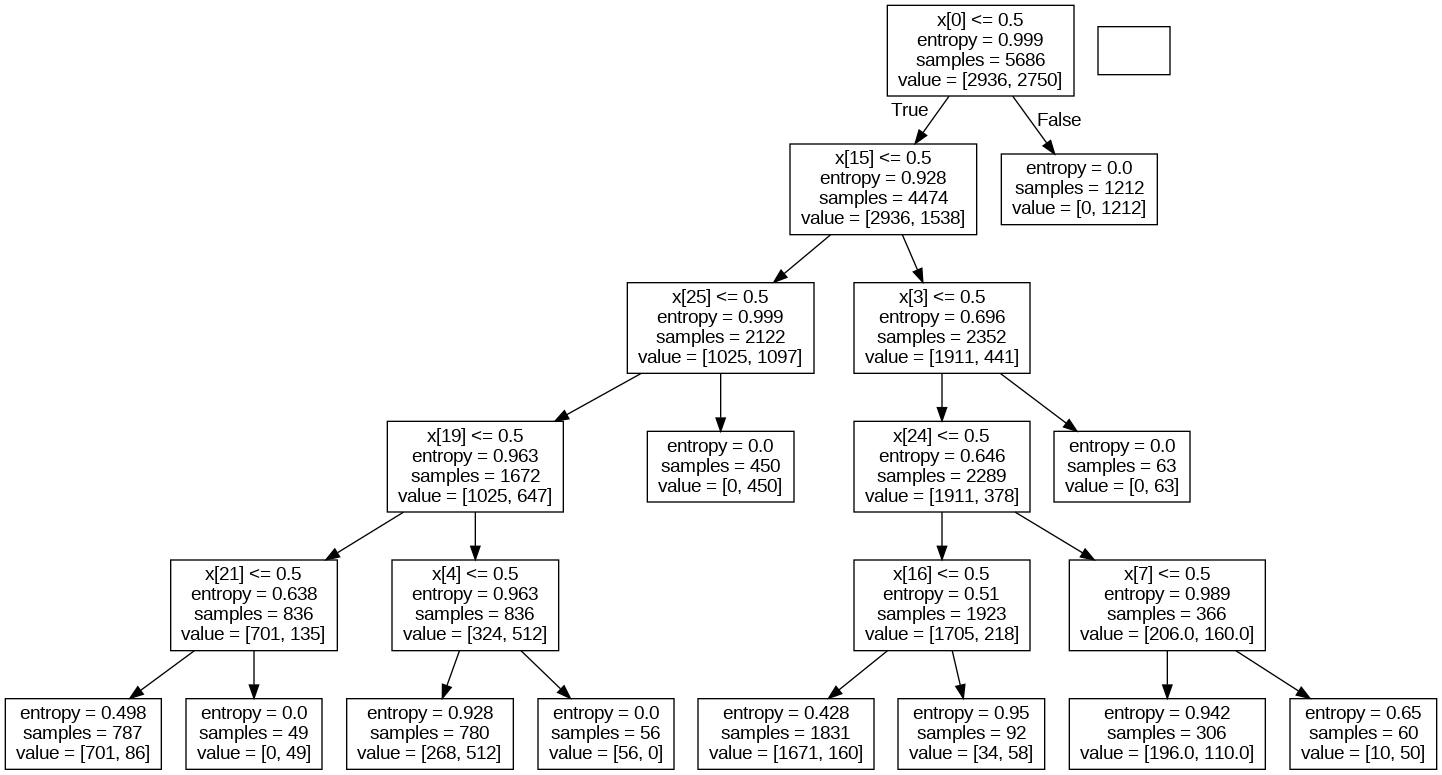

In [42]:
from sklearn import tree
import pydotplus
from io import StringIO  # ← ここを修正（sklearnからではなく、ioから読み込む）
from IPython.display import Image

dot_data = StringIO()
tree.export_graphviz(model, out_file=dot_data)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())